# Visualising complex data in Astronomy
## Author: Princy Ranaivomanana
#### For more information about the method, see https://arxiv.org/abs/2411.18609

This notebook demonstrates an **unsupervised machine-learning workflow** for a Gaia-derived feature set:

1. Load and inspect the Gaia feature catalogue.
2. Select the numerical features and handle missing values.
3. Standardise the features.
4. Visualise the data with **PCA**, **t-SNE**, **UMAP**.
5. Remove highly correlated features and repeat the t-SNE visualisation.
6. Use a **Gaussian Mixture Model (GMM)** to identify three groups in the t-SNE embedding.
7. Build a **UMAP** embedding and repeat the GMM clustering.
8. Compare the resulting embedding with known object types from **SIMBAD**.


## 1. Workflow at a glance

The main data flow is:

**Gaia feature table → feature selection → missing-value filtering → standardisation → dimensionality reduction → clustering → comparison with SIMBAD**

We will keep the dimensionality-reduction methods conceptually separate:

- **PCA** is a linear transformation that preserves directions of largest variance.
- **t-SNE** is primarily a visualisation method designed to preserve local neighbourhood structure.
- **UMAP** is a nonlinear embedding method that can also preserve local structure while often retaining more global organisation than t-SNE.

The clustering step uses a **Gaussian Mixture Model (GMM)** with three components, following the original analysis.


## 2. Imports and reproducibility

The imports below contain the tools used throughout the notebook. A fixed random seed is used wherever the algorithm supports one so that the tutorial results are reproducible as far as the underlying library versions allow.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# UMAP is used later in the notebook.
import umap


# Reproducibility
RANDOM_STATE = 42

# Input files
GAIA_FILE = Path("hsd_Gaia_84features_and_ids.csv")
SIMBAD_FILE = Path("hsd_culpan_gaia_vari_summary_classification_4simbad.csv")

# A consistent plotting style for the tutorial.
plt.rcParams.update({
    "figure.figsize": (8, 6),
    "figure.dpi": 120,
    "axes.grid": False,
})


## 3. Load the Gaia catalogue

The main file is expected to contain the Gaia source identifiers followed by the numerical features used for the machine-learning analysis.

We will inspect the shape and column names before selecting the feature matrix. This is a useful habit in a tutorial: **always verify what the data contain before applying a model.**


In [2]:
data = pd.read_csv(GAIA_FILE)

print(f"Catalogue shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
print("\nFirst columns:")
print(data.columns[:10].tolist())


Catalogue shape: 1,668 rows × 87 columns

First columns:
['ra', 'dec', 'source_id_1', 'parallax', 'parallax_error', 'phot_g_mean_mag', 'bp_rp', 'phot_g_n_obs', 'G_abs', 'log_sigvar']


In [3]:
data.head()

,ra,dec,source_id_1,parallax,parallax_error,phot_g_mean_mag,bp_rp,phot_g_n_obs,G_abs,log_sigvar,...,kurtosis_mag_rp,mad_mag_rp,abbe_mag_rp,iqr_mag_rp,stetson_mag_rp,std_dev_over_rms_err_mag_rp,outlier_median_rp,n05,psi_sigvar,rms_over_ptp_amp
0,117.956776,-23.989505,5710645592594769280,0.751949,0.060421,17.199503,0.421589,671,6.566167,3.830883,...,2.205996,0.504103,1.051495,0.732738,17.605177,22.497107,314.299650,1.0,0.007132,5.658358
1,218.250690,-61.354813,5878353036051735424,1.478345,0.021627,15.063677,0.222188,555,5.911859,4.476104,...,5.156419,0.787269,0.925002,1.037890,93.453316,108.110374,2283.703600,2.0,0.008452,8.217070
2,23.052865,-49.561279,4929394649214080896,0.949878,0.026961,14.297598,-0.350369,587,4.183801,3.234852,...,-1.434759,0.185192,1.151051,0.223578,16.586237,25.239822,44.357616,1.0,0.007651,14.759161
3,160.188244,-54.303468,5353877945092382336,0.406033,0.046704,16.603773,0.060724,402,4.641633,3.934067,...,-1.402852,0.617353,1.120144,0.877846,20.864864,26.230268,90.345930,1.0,0.008195,7.672653
4,126.958753,-27.610520,5646693014160460416,0.383335,0.053360,16.869673,-0.186270,690,4.784816,3.308422,...,1.330468,0.308560,1.232676,0.448936,5.905924,13.610375,96.989480,1.0,0.005691,18.252163


### Selecting the feature matrix

In the original analysis, the first three columns are treated as identifiers/metadata, while columns from position 3 onward are treated as numerical features.

We therefore select:

```python
data.iloc[:, 3:]
```

and remove rows containing missing values **within the feature matrix**.

Keeping the row index is important: it lets us reconnect the machine-learning results to the original catalogue later.


In [4]:
features = data.iloc[:, 3:].dropna()

print(f"Feature matrix shape after removing missing feature values: {features.shape}")
print(f"Number of features: {features.shape[1]}")


Feature matrix shape after removing missing feature values: (1564, 84)
Number of features: 84


In [5]:
features.head()

,parallax,parallax_error,phot_g_mean_mag,bp_rp,phot_g_n_obs,G_abs,log_sigvar,std,frac_period,N_G,...,kurtosis_mag_rp,mad_mag_rp,abbe_mag_rp,iqr_mag_rp,stetson_mag_rp,std_dev_over_rms_err_mag_rp,outlier_median_rp,n05,psi_sigvar,rms_over_ptp_amp
0,0.751949,0.060421,17.199503,0.421589,671,6.566167,3.830883,0.000002,341891.219060,78,...,2.205996,0.504103,1.051495,0.732738,17.605177,22.497107,314.299650,1.0,0.007132,5.658358
1,1.478345,0.021627,15.063677,0.222188,555,5.911859,4.476104,0.000005,63171.835967,63,...,5.156419,0.787269,0.925002,1.037890,93.453316,108.110374,2283.703600,2.0,0.008452,8.217070
2,0.949878,0.026961,14.297598,-0.350369,587,4.183801,3.234852,0.000001,402320.533690,70,...,-1.434759,0.185192,1.151051,0.223578,16.586237,25.239822,44.357616,1.0,0.007651,14.759161
3,0.406033,0.046704,16.603773,0.060724,402,4.641633,3.934067,0.000005,65746.399171,46,...,-1.402852,0.617353,1.120144,0.877846,20.864864,26.230268,90.345930,1.0,0.008195,7.672653
4,0.383335,0.053360,16.869673,-0.186270,690,4.784816,3.308422,0.007893,14.249030,80,...,1.330468,0.308560,1.232676,0.448936,5.905924,13.610375,96.989480,1.0,0.005691,18.252163


## 4. Standardise the features

Different Gaia-derived features can have very different numerical scales. For example, a feature measured in a large numerical range can dominate distance-based calculations simply because of its units.

We use **z-score standardisation**:
$$
[
x_{scaled} = \frac{x - \mu}{\sigma}
]
$$
After scaling, each feature has approximately zero mean and unit standard deviation.

This step is especially important before PCA, t-SNE, UMAP, and GMM because their results depend on the geometry of the feature space.


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(f"Scaled matrix shape: {X_scaled.shape}")
print(f"Mean of first five scaled features: {X_scaled[:, :5].mean(axis=0)}")
print(f"Std. of first five scaled features:  {X_scaled[:, :5].std(axis=0)}")


Scaled matrix shape: (1564, 84)
Mean of first five scaled features: [-1.31750252e-16  1.49922700e-16 -2.19886627e-15  1.81724485e-17
 -8.17760182e-17]
Std. of first five scaled features:  [1. 1. 1. 1. 1.]


## 5. PCA: a first look at the feature space

PCA finds orthogonal directions that explain the largest variance in the data. Here we project the standardised feature matrix onto its first two principal components.

PCA is **linear**, so it is useful as a simple baseline before moving to nonlinear methods.


In [7]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("Explained variance ratio:")
print(f"  PC1: {explained_variance[0]:.3f}")
print(f"  PC2: {explained_variance[1]:.3f}")
print(f"  PC1 + PC2: {explained_variance.sum():.3f}")


Explained variance ratio:
  PC1: 0.320
  PC2: 0.155
  PC1 + PC2: 0.475


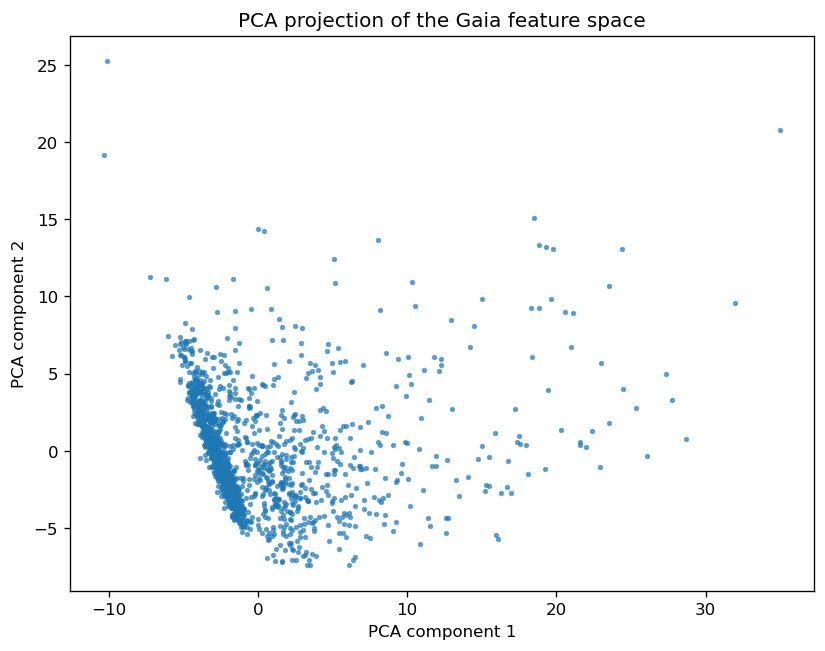

In [8]:
plt.figure()
plt.scatter(pca_components[:, 0], pca_components[:, 1], s=5, alpha=0.6)
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("PCA projection of the Gaia feature space")
plt.show()


## 6. t-SNE: visualising local structure

t-SNE is a nonlinear dimensionality-reduction method designed mainly for visualisation. It tries to place objects with similar local neighbourhoods close together in two dimensions.

One important parameter is **perplexity**, which roughly controls the effective size of the local neighbourhood considered by t-SNE. There is no universally correct value, so it is useful to check whether the visual structure is stable when the value changes.

The original notebook used perplexities of 50 and 30. We retain both as a simple sensitivity check.


In [10]:
# First t-SNE experiment: perplexity = 50
tsne_50 = TSNE(
    n_components=2,
    perplexity=50,
    learning_rate=200,
    n_iter=1000,
    random_state=RANDOM_STATE,
    init="pca",
)

embedding_tsne_50 = tsne_50.fit_transform(X_scaled)


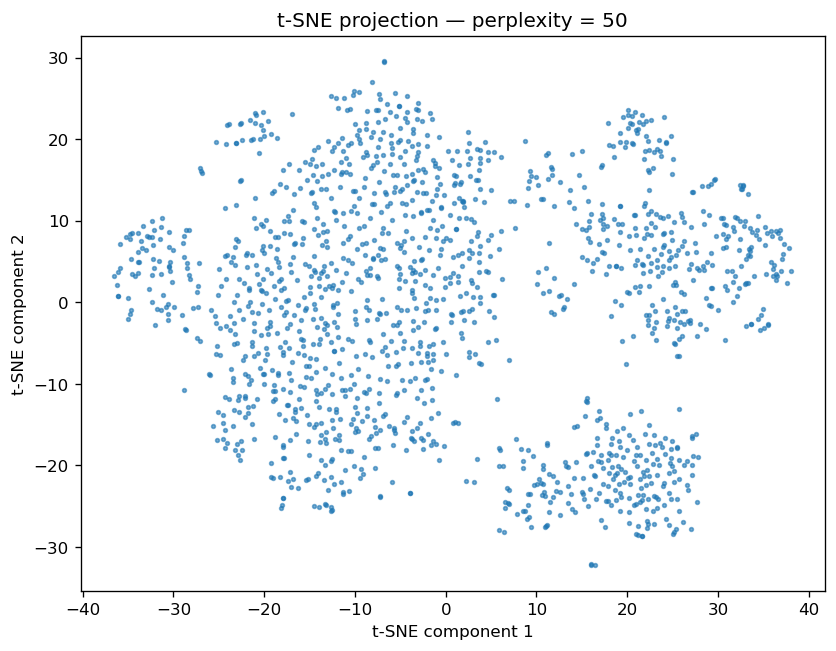

In [11]:
plt.figure()
plt.scatter(embedding_tsne_50[:, 0], embedding_tsne_50[:, 1], s=5, alpha=0.6)
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.title("t-SNE projection — perplexity = 50")
plt.show()


In [13]:
# Second t-SNE experiment: perplexity = 30
tsne_30_initial = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=RANDOM_STATE,
    init="pca",
)

embedding_tsne_30_initial = tsne_30_initial.fit_transform(X_scaled)


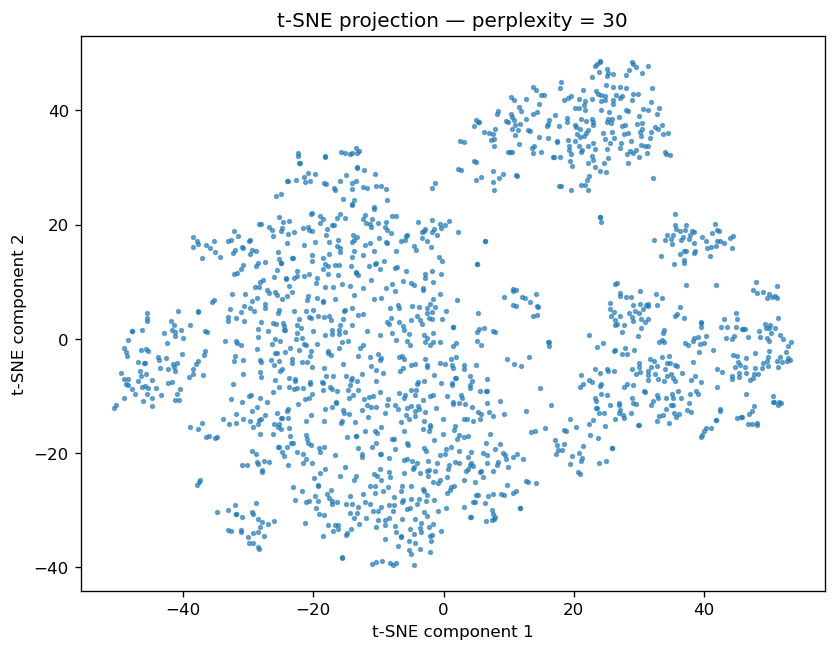

In [14]:
plt.figure()
plt.scatter(
    embedding_tsne_30_initial[:, 0],
    embedding_tsne_30_initial[:, 1],
    s=5,
    alpha=0.6,
)
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.title("t-SNE projection — perplexity = 30")
plt.show()


### What should you look for?

Do not interpret every visible island as a physical class. t-SNE can create visually separated groups even when the high-dimensional structure is more continuous.

Instead, ask:

- Are broad structures stable when the perplexity changes?
- Are there obvious outliers?
- Do neighbouring points appear to form meaningful populations?
- Can these patterns be connected to independent information, such as SIMBAD classifications?

These questions are more informative than simply asking whether the plot “looks clustered.”


## 7. Remove highly correlated features

Many feature catalogues contain multiple measurements that carry nearly the same information. Strongly correlated features can make the representation unnecessarily redundant.

Here we follow the original analysis and remove one feature from each pair whose absolute Pearson correlation exceeds **0.95**.

This is a simple feature-reduction rule, not a claim that 0.95 is universally optimal.


In [15]:
correlation_matrix = features.corr().abs()

upper_triangle_mask = np.triu(
    np.ones(correlation_matrix.shape),
    k=1
).astype(bool)

upper_triangle = correlation_matrix.where(upper_triangle_mask)

CORRELATION_THRESHOLD = 0.95

to_drop = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > CORRELATION_THRESHOLD)
]

data_reduced = features.drop(columns=to_drop)

print(f"Original number of features: {features.shape[1]}")
print(f"Features removed:             {len(to_drop)}")
print(f"Remaining features:          {data_reduced.shape[1]}")


Original number of features: 84
Features removed:             35
Remaining features:          49


### Re-standardise after feature selection

The feature set has changed, so we standardise the reduced feature matrix again before applying t-SNE and UMAP.


In [16]:
scaler_reduced = StandardScaler()
X_scaled_reduced = scaler_reduced.fit_transform(data_reduced)

feature_names = data_reduced.columns


## 8. Final t-SNE embedding used for clustering

We now calculate the t-SNE embedding with the reduced feature set and perplexity 30. This embedding is the one used by the following GMM clustering analysis.


In [18]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=RANDOM_STATE,
    init="pca",
)

embedding_tsne = tsne.fit_transform(X_scaled_reduced)


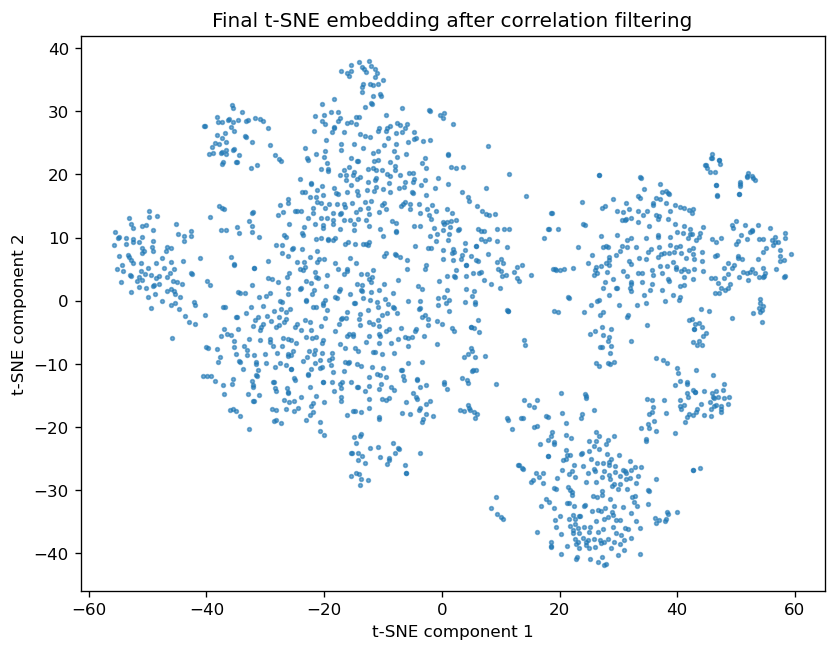

In [19]:
plt.figure()
plt.scatter(embedding_tsne[:, 0], embedding_tsne[:, 1], s=5, alpha=0.6)
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.title("Final t-SNE embedding after correlation filtering")
plt.show()


## 9. Gaussian Mixture Model (GMM) clustering on t-SNE

A Gaussian Mixture Model assumes that the data can be represented as a mixture of Gaussian probability distributions.

Here we use **three components**, matching the original analysis. GMM is a *soft* clustering model: instead of only assigning an object to a cluster, it can also provide probabilities for membership.

For this tutorial, we use the most probable component as the cluster label.

In [20]:
gmm_tsne = GaussianMixture(
    n_components=3,
    covariance_type="diag",
    n_init=10,
    random_state=RANDOM_STATE,
)

gmm_tsne.fit(embedding_tsne)

labels_gmm_tsne = gmm_tsne.predict(embedding_tsne)
cluster_probabilities_tsne = gmm_tsne.predict_proba(embedding_tsne)

print("Cluster counts:")
print(pd.Series(labels_gmm_tsne).value_counts().sort_index())


Cluster counts:
0    359
1    982
2    223
Name: count, dtype: int64


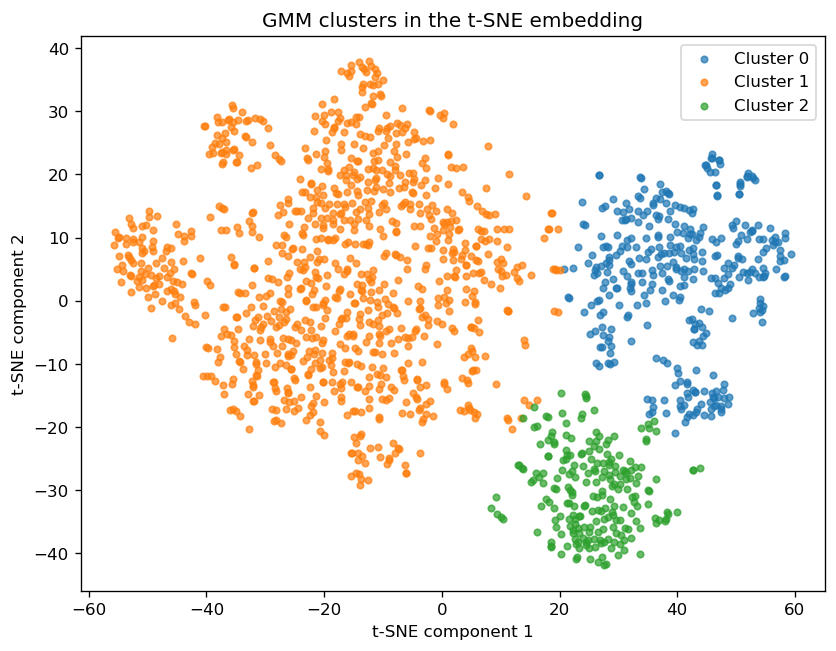

Silhouette score:          0.489
Calinski–Harabasz score:   1723.813


In [21]:
plt.figure()

for label in np.unique(labels_gmm_tsne):
    mask = labels_gmm_tsne == label
    plt.scatter(
        embedding_tsne[mask, 0],
        embedding_tsne[mask, 1],
        s=15,
        alpha=0.7,
        label=f"Cluster {label}",
    )

plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.title("GMM clusters in the t-SNE embedding")
plt.legend()
plt.show()

silhouette_tsne = silhouette_score(embedding_tsne, labels_gmm_tsne)
calinski_tsne = calinski_harabasz_score(embedding_tsne, labels_gmm_tsne)

print(f"Silhouette score:          {silhouette_tsne:.3f}")
print(f"Calinski–Harabasz score:   {calinski_tsne:.3f}")


### Interpreting the clustering metrics

- **Silhouette score:** compares how close each object is to its own cluster relative to the nearest other cluster. Larger values generally indicate better separation in the space being evaluated.
- **Calinski–Harabasz score:** compares between-cluster dispersion with within-cluster dispersion. Larger values generally indicate stronger separation.

Here, both scores are calculated **in the 2-D t-SNE space**, so they quantify separation of the GMM labels in that embedding—not classification accuracy and not astrophysical correctness.


## 10. UMAP: an alternative nonlinear embedding

UMAP provides another way to project the high-dimensional feature space into two dimensions.

We use the reduced, standardised features and `n_neighbors=15`, following the original notebook. The parameter controls the approximate neighbourhood scale used to construct the manifold representation.


In [22]:
reducer = umap.UMAP(
    metric="euclidean",
    n_neighbors=15,
    random_state=RANDOM_STATE,
)

embedding_umap = reducer.fit_transform(X_scaled_reduced)


/Users/princy/opt/anaconda3/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


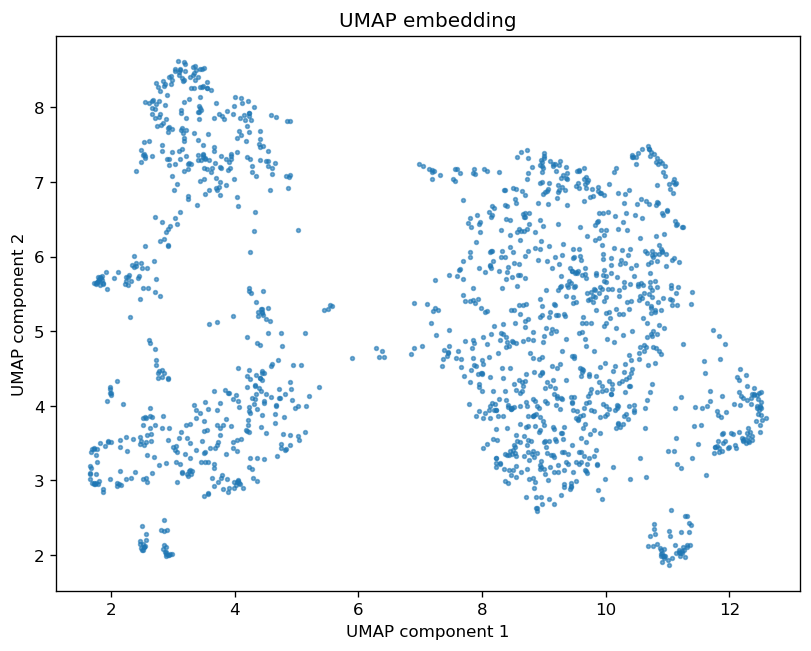

In [23]:
plt.figure()
plt.scatter(embedding_umap[:, 0], embedding_umap[:, 1], s=5, alpha=0.6)
plt.xlabel("UMAP component 1")
plt.ylabel("UMAP component 2")
plt.title("UMAP embedding")
plt.show()


## 11. GMM clustering in the UMAP embedding

We repeat the clustering analysis in UMAP space. The original notebook used a **tied covariance** GMM here, so that choice is retained.

Comparing the UMAP and t-SNE results is useful for assessing whether the broad population structure is robust to the choice of embedding method.


In [24]:
gmm_umap = GaussianMixture(
    n_components=3,
    covariance_type="tied",
    n_init=10,
    random_state=RANDOM_STATE,
)

gmm_umap.fit(embedding_umap)

labels_gmm_umap = gmm_umap.predict(embedding_umap)


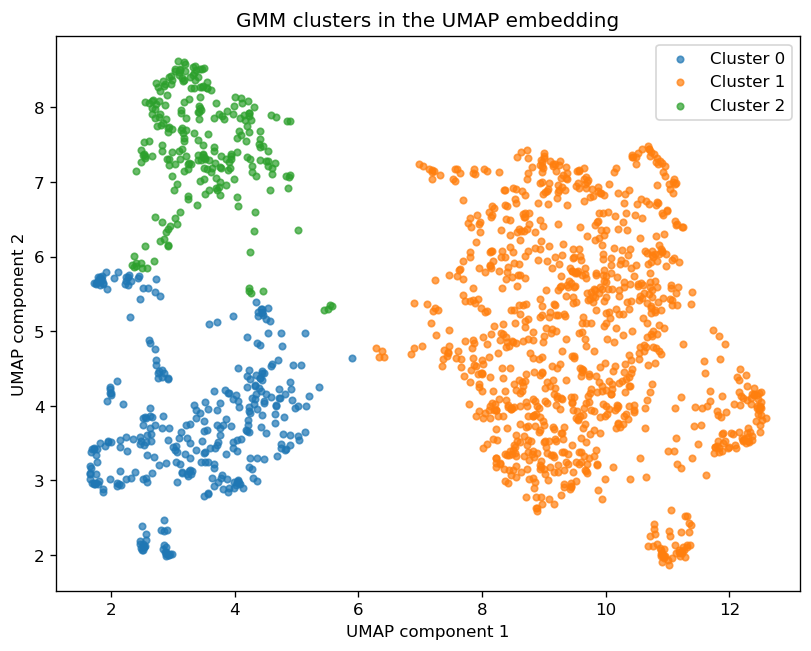

Silhouette score:          0.597
Calinski–Harabasz score:   2885.671


In [25]:
plt.figure()

for label in np.unique(labels_gmm_umap):
    mask = labels_gmm_umap == label
    plt.scatter(
        embedding_umap[mask, 0],
        embedding_umap[mask, 1],
        s=15,
        alpha=0.7,
        label=f"Cluster {label}",
    )

plt.xlabel("UMAP component 1")
plt.ylabel("UMAP component 2")
plt.title("GMM clusters in the UMAP embedding")
plt.legend()
plt.show()

silhouette_umap = silhouette_score(embedding_umap, labels_gmm_umap)
calinski_umap = calinski_harabasz_score(embedding_umap, labels_gmm_umap)

print(f"Silhouette score:          {silhouette_umap:.3f}")
print(f"Calinski–Harabasz score:   {calinski_umap:.3f}")


## 12. Connect the embeddings back to the Gaia catalogue

The machine-learning arrays contain only the rows that survived feature-level missing-value filtering.

A subtle but important point is that we should **not** simply call `data.dropna()` here: that could remove additional rows because of missing values in unrelated metadata columns and make the embedding labels misaligned with the catalogue.

Instead, we use the exact index of `features`, which is the population used by the ML analysis.


In [26]:
data_clean = data.loc[features.index].copy()

# Add the final t-SNE labels and coordinates.
data_clean["tsne_labels"] = labels_gmm_tsne
data_clean[["tsne1", "tsne2"]] = embedding_tsne

print(f"Rows in ML sample: {len(data_clean):,}")
print(f"Rows in t-SNE embedding: {len(embedding_tsne):,}")


Rows in ML sample: 1,564
Rows in t-SNE embedding: 1,564


## 13. Bring in independent SIMBAD classifications

The second catalogue contains object classifications from SIMBAD. We use it **after** the unsupervised analysis so that these labels do not influence the clustering.

The merge is performed using `source_id_1`.


In [27]:
simbad = pd.read_csv(SIMBAD_FILE)

print(f"SIMBAD table shape: {simbad.shape}")
simbad.head()


SIMBAD table shape: (1563, 107)


,source_id_1,ra,dec,parallax,parallax_error,phot_g_mean_mag,bp_rp,phot_g_n_obs,G_abs,log_sigvar,...,rms_over_ptp_amp,labels,label_gm_umap,label_gm,manual_label,tsne1,tsne2,umap1,umap2,main_type
0,5710645592594769280,117.956776,-23.989505,0.751949,0.060421,17.199503,0.421589,671,6.566167,3.830883,...,5.658358,0.0,2,0,0,32.986187,-30.359999,4.501324,1.946776,RRLyr
1,5878353036051735424,218.250690,-61.354813,1.478345,0.021627,15.063677,0.222188,555,5.911859,4.476104,...,8.217070,0.0,2,0,0,32.847275,-30.347029,4.600111,1.985806,Hsd_Candidate
2,4929394649214080896,23.052865,-49.561279,0.949878,0.026961,14.297598,-0.350369,587,4.183801,3.234852,...,14.759161,0.0,2,0,0,30.661913,-30.981749,4.379964,1.910600,RRLyr
3,5353877945092382336,160.188244,-54.303468,0.406033,0.046704,16.603773,0.060724,402,4.641633,3.934067,...,7.672653,0.0,2,2,0,42.718820,-4.306637,4.633800,2.124264,Star
4,5646693014160460416,126.958753,-27.610520,0.383335,0.053360,16.869673,-0.186270,690,4.784816,3.308422,...,18.252163,0.0,2,0,0,31.241892,-31.210590,4.456262,1.915930,Star


In [28]:
data_with_labels = pd.merge(
    data_clean,
    simbad[["source_id_1", "main_type"]],
    on="source_id_1",
    how="inner",
)

print(f"Rows after merging with SIMBAD: {len(data_with_labels):,}")
print("\nAvailable main types (top 15):")
print(data_with_labels["main_type"].value_counts().head(15))


Rows after merging with SIMBAD: 1,563

Available main types (top 15):
main_type
Hsd_Candidate    582
HotSubdwarf      548
Star             175
CataclyV*         97
V*                40
EB*               30
WD*               10
RSCVn              9
PN                 9
RRLyr              8
PulsV*             6
CV*_Candidate      6
PulsV*delSct       4
Nova               3
BYDra              3
Name: count, dtype: int64


### Select the reference object types

The original analysis highlights four SIMBAD categories:

- `HotSubdwarf`
- `CataclyV*` — cataclysmic variables
- `EB*` — eclipsing binaries
- `WD*` — white dwarfs

We keep the exact SIMBAD strings used by the source notebook.


In [29]:
hsd = data_with_labels[data_with_labels["main_type"] == "HotSubdwarf"]
CV = data_with_labels[data_with_labels["main_type"] == "CataclyV*"]
EB = data_with_labels[data_with_labels["main_type"] == "EB*"]
WD = data_with_labels[data_with_labels["main_type"] == "WD*"]

print(f"Known hot subdwarfs:          {len(hsd):,}")
print(f"Cataclysmic variables:        {len(CV):,}")
print(f"Eclipsing binaries:           {len(EB):,}")
print(f"White dwarfs:                 {len(WD):,}")


Known hot subdwarfs:          548
Cataclysmic variables:        97
Eclipsing binaries:           30
White dwarfs:                 10


## 14. Compare the t-SNE structure with SIMBAD types

This final plot overlays known SIMBAD object types on the same t-SNE embedding.

The purpose is **not** to claim that the unsupervised clusters are identical to the SIMBAD classes. Instead, use the plot to ask whether independently labelled populations occupy distinct or overlapping regions of feature space.

Also note that only the three explicitly plotted classes are highlighted; the background contains all objects available after the merge.


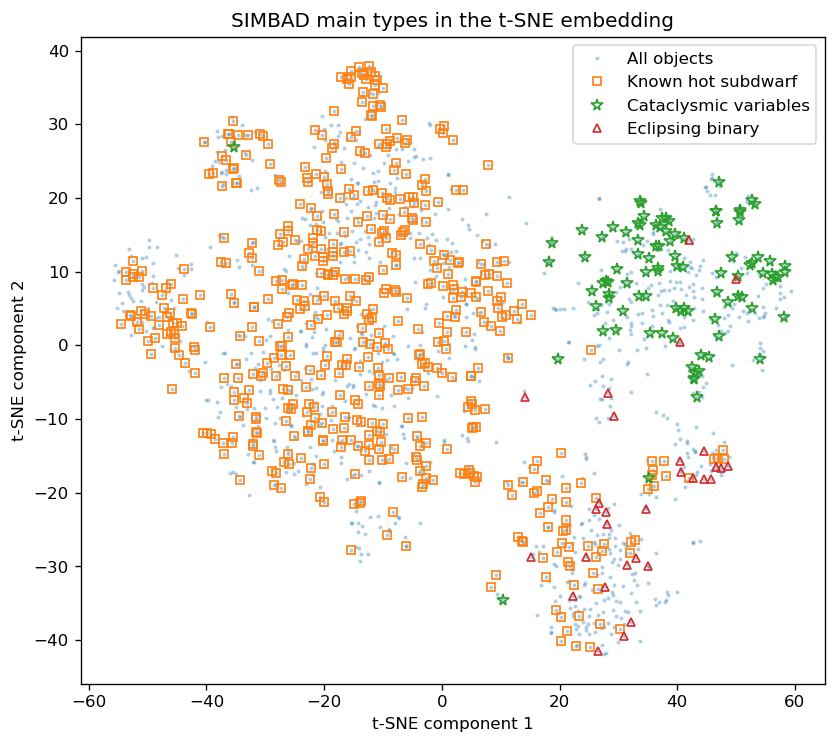

In [30]:
plt.figure(figsize=(8, 7))

plt.plot(
    data_with_labels["tsne1"],
    data_with_labels["tsne2"],
    ".",
    markersize=3,
    alpha=0.25,
    label="All objects",
)

plt.plot(
    hsd["tsne1"],
    hsd["tsne2"],
    "s",
    markersize=5,
    markerfacecolor="none",
    label="Known hot subdwarf",
)

plt.plot(
    CV["tsne1"],
    CV["tsne2"],
    "*",
    markersize=7,
    markerfacecolor="none",
    label="Cataclysmic variables",
)

plt.plot(
    EB["tsne1"],
    EB["tsne2"],
    "^",
    markersize=5,
    markerfacecolor="none",
    label="Eclipsing binary",
)

plt.title("SIMBAD main types in the t-SNE embedding")
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.legend()
plt.show()


## 15. Summary and discussion questions

### What we did

- Started with the Gaia-derived feature catalogue.
- Removed objects with missing values in the ML feature set.
- Standardised the features.
- Examined the data with PCA and t-SNE.
- Removed one feature from highly correlated pairs (`|r| > 0.95`).
- Used t-SNE and UMAP as nonlinear visualisations.
- Applied three-component GMM clustering to the embeddings.
- Quantified cluster separation with silhouette and Calinski–Harabasz scores.
- Compared the resulting feature-space structure with independent SIMBAD classifications.
